## Architecture of the U-Net

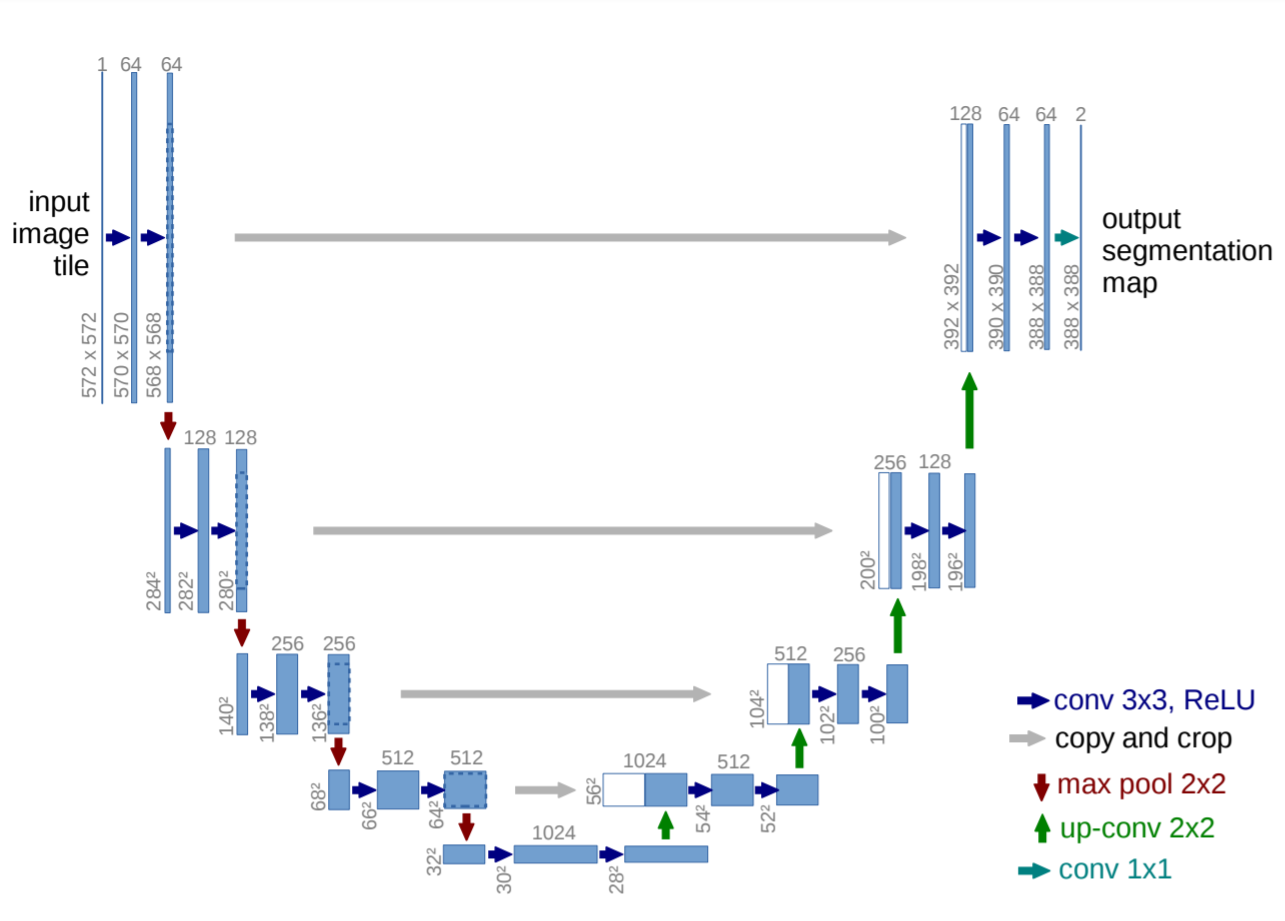

The complete architecture consists of two parts:
1. Encoder (left) &rarr; downsampling
2. Decoder (right) &rarr; upscaling

Here the encoder doubles the number of channels in every step and halves the number of spatial dimension.
Whereas the decoder does the opposite of what the encoder does here.

##### imports

In [23]:
import torch
import torchvision
import torch.nn as nn

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Torch version: 2.12.0
Torchvision version: 0.27.0


##### doubleConv block ~

{ conv 3x3 &rarr; ReLU } x 2 &rarr; 64ch
(unpadded convolutions)

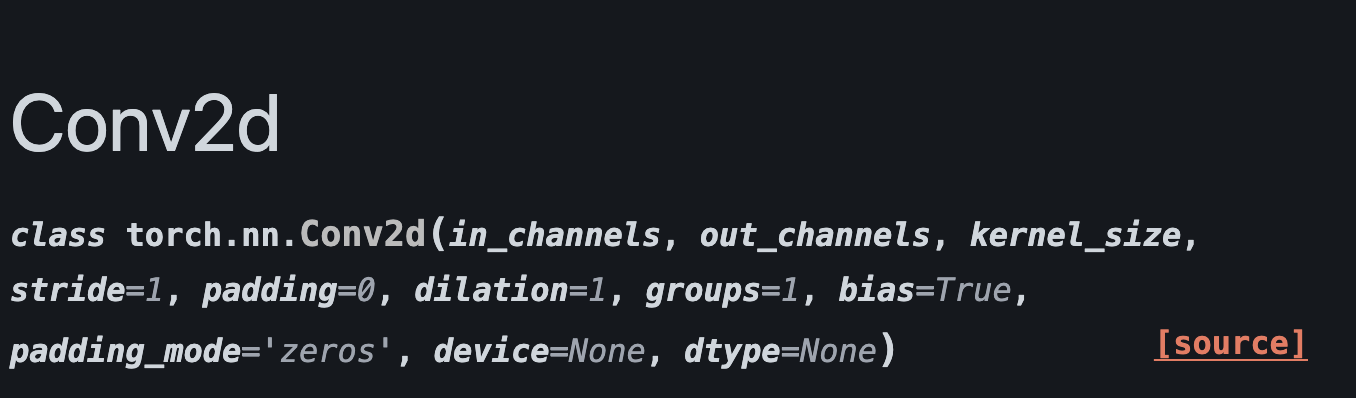
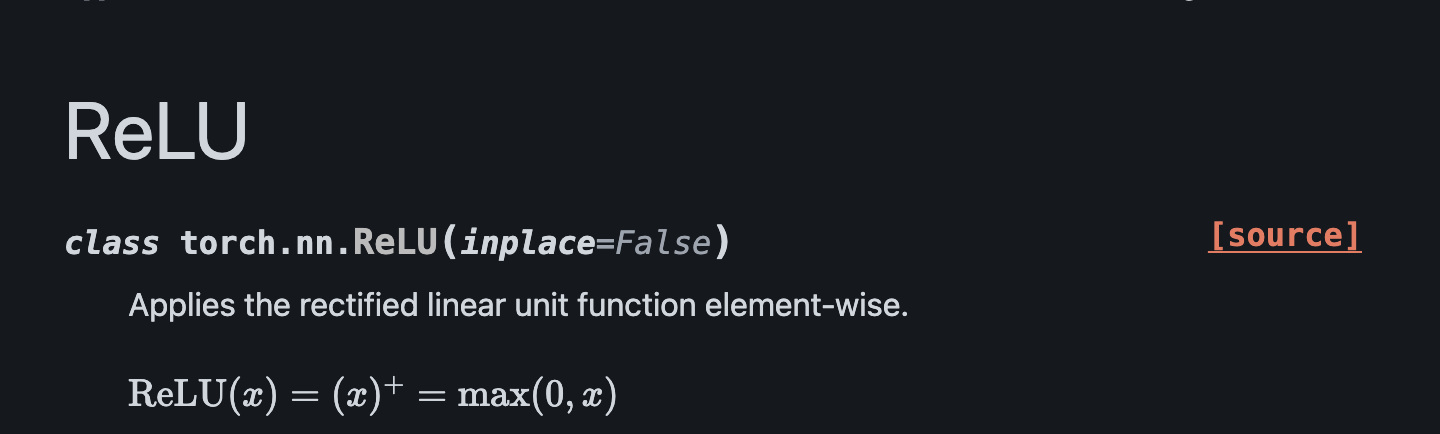

In [24]:
class doubleConv(nn.Module):
    def __init__(self , input_ch , output_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(input_ch , output_ch , 3) #no padding
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(output_ch , output_ch , 3) #no padding
    def forward(self , x):
        return self.relu(self.conv2(self.relu(self.conv1(x))))



##### The above cell can also be implemented directly by nn.Sequential rather than implementing inside the init.

here is a note on when to use inplace = True or false inside the ReLU

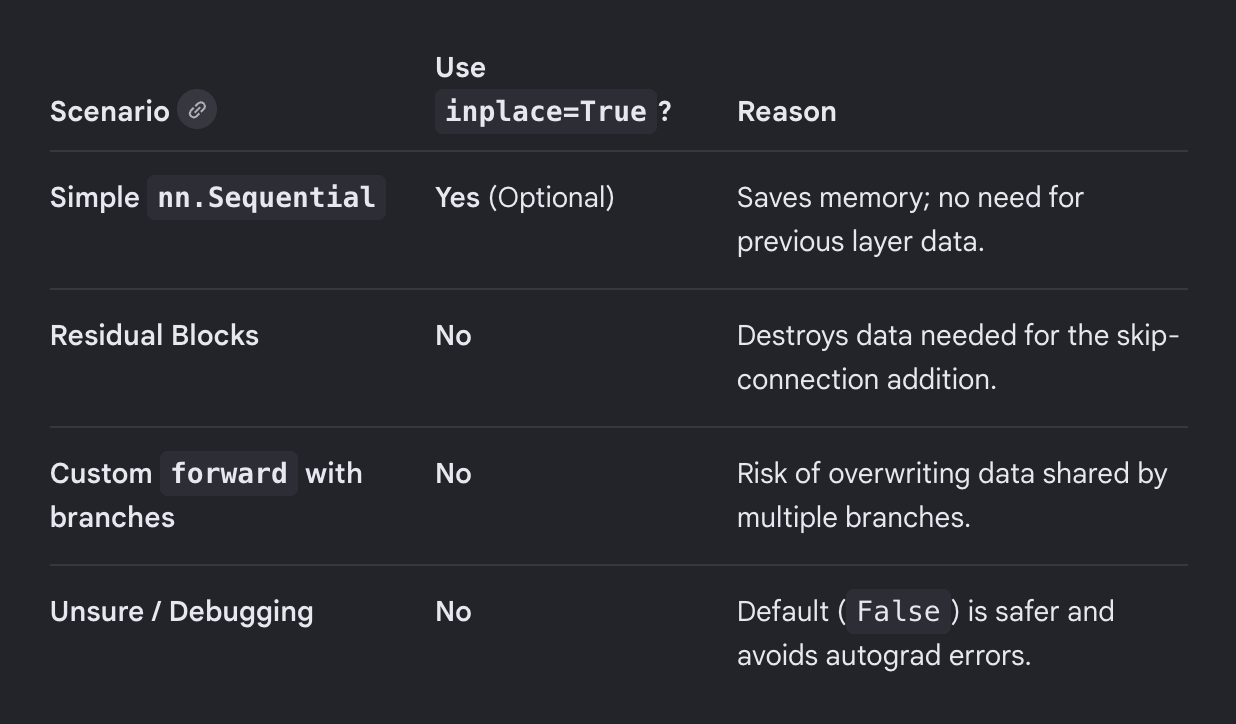

In [25]:
# class doubleConv(nn.Module):
#     def __init__(self , input_ch , output_ch):
#         super().__init__()

#         self.net = nn.Sequential(
#         nn.Conv2d(input_ch , output_ch , 3), #no padding
#         nn.ReLU(),
#         nn.Conv2d(output_ch , output_ch , 3), #no padding
#         nn.ReLU()
#         )
#     def forward(self , x):
#         return self.net(x)


In [26]:
enc_block = doubleConv(1,64)
x = torch.randn(1,1,572,572)
enc_block(x).shape

torch.Size([1, 64, 568, 568])

this implies that &rArr; given an input image with shape 1x572x572 the output is 64x568x568

##### Encoder Block

It's the contractive path of the U-Net Architecture. Above we have implemented the convolution operations but not the downsampling part. We need to do the max pool operation as mentioned in the paper.

Each block is followed by a 2x2 max pooling operation with stride = 2 for downsampling.\
At each downsampling step we double the number of feature
channels. \
here we are having 3 input channels ( the paper uses 1-channel EM images though, but we are good to go by 3 :P)\
chs = (3,64,128,256,512,1024)


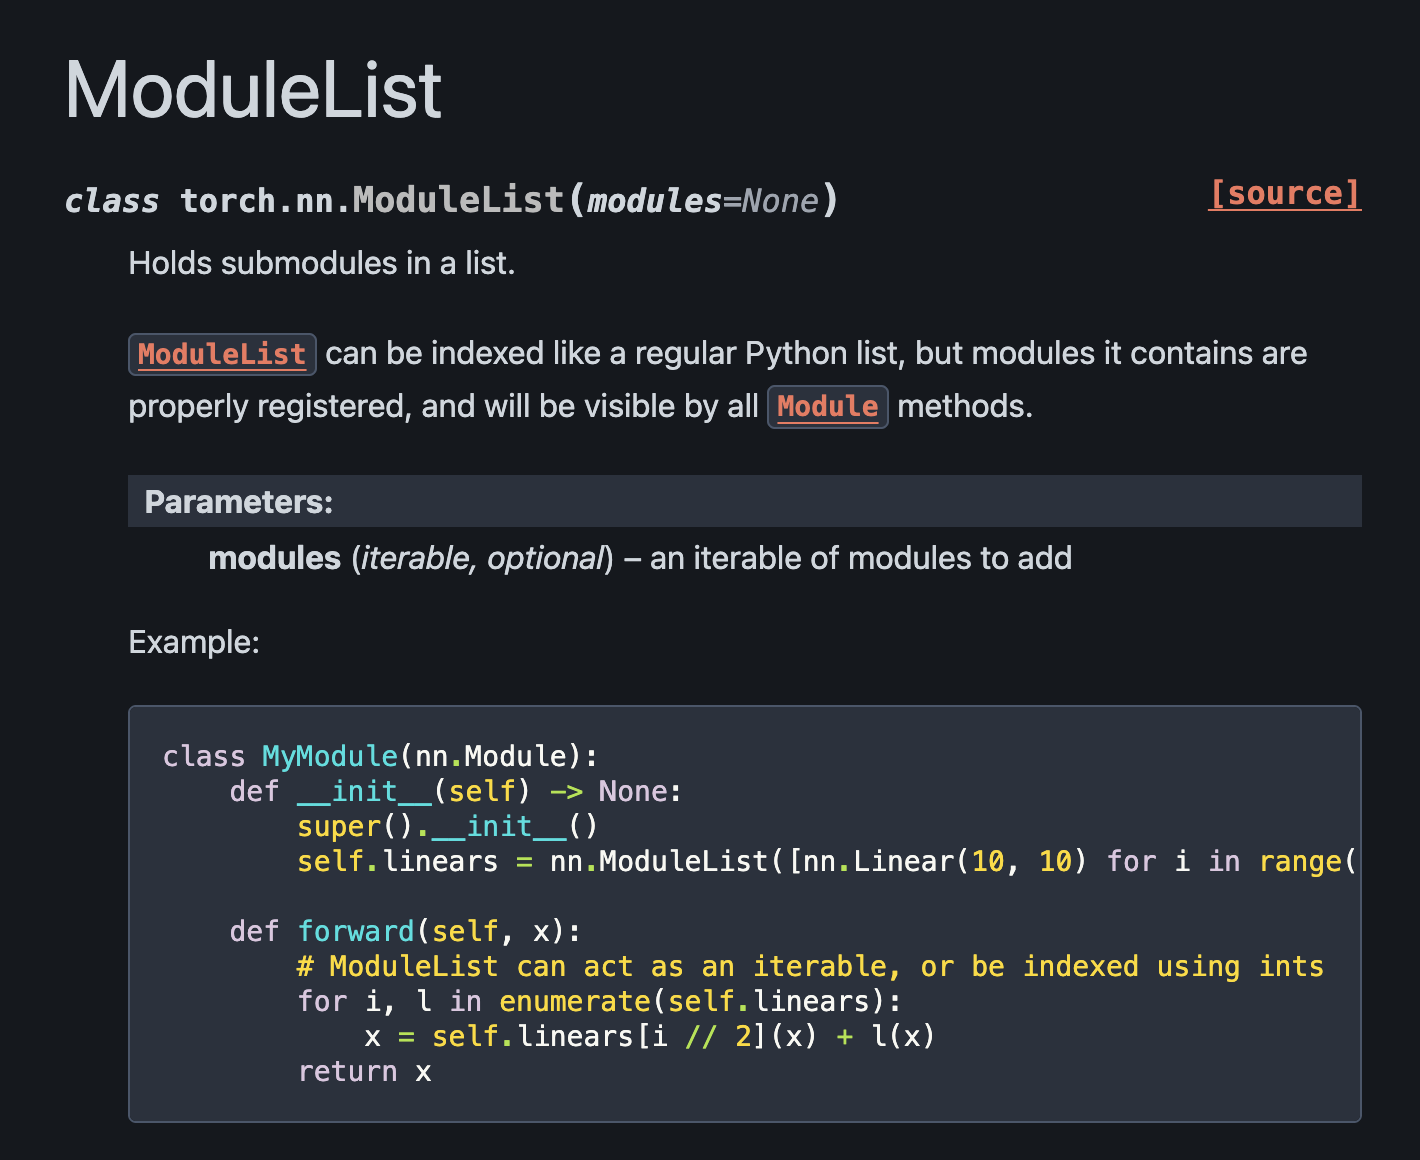

In [27]:
class Encoder(nn.Module):
    def __init__(self, chs = (3,64,128,256,512,1024)):
        super().__init__()
        self.enc_blocks = nn.ModuleList(
            [doubleConv(chs[i] , chs[i+1]) for i in range(len(chs) -1)]
            # this is the list of the double convolution operation we defined above
        )
        self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        ftrs = [] #collects output of each block before pooling, this is the skip connecttion
        for block in self.enc_blocks:
            x = block(x)
            ftrs.append(x)
            x = self.pool(x)
        return ftrs

let's verify our encoder block by testing with the original input

In [28]:
encoder = Encoder()
#input image
x = torch.randn(1,3,572,572)
ftrs = encoder(x)
for ftr in ftrs:
    print(ftr.shape)
print("It worked!")

torch.Size([1, 64, 568, 568])
torch.Size([1, 128, 280, 280])
torch.Size([1, 256, 136, 136])
torch.Size([1, 512, 64, 64])
torch.Size([1, 1024, 28, 28])
It worked!


##### Decoder

It is the expansive part of the U-Net architecture.

Every step in the expansive path consists of an upsampling of the
feature map followed by a 2x2 convolution (“up-convolution”) that halves the
number of feature channels, a concatenation with the correspondingly cropped
feature map from the contracting path, and two 3x3 convolutions, each followed by a ReLU.\
The cropping is necessary due to the loss of border pixels in
every convolution.\
At the final layer a 1x1 convolution is used to map each 64-
component feature vector to the desired number of classes. 


Up-convolution here can be done by the ConvTranspose2D.

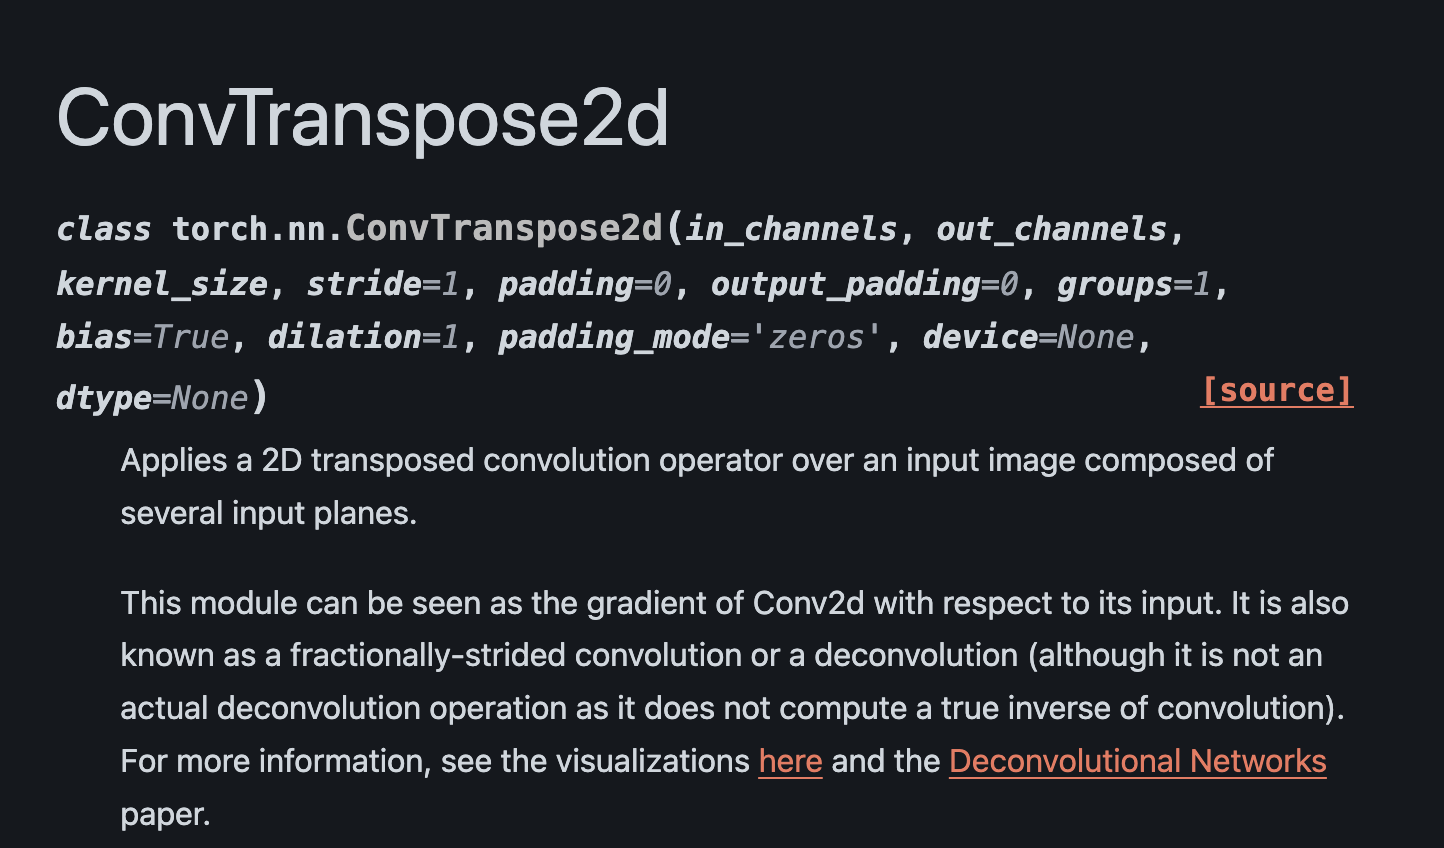

here our channel sizes will be deremented so\
chs = (1024, 512 , 256 , 128 , 64 )

(1, 1024, 28, 28) → up-conv 2×2 → (1, 512, 56, 56)

In [29]:
class Decoder(nn.Module):
    def __init__(self , chs = (1024, 512 , 256 , 128 , 64 )):
        super().__init__()
        self.chs = chs
        self.upconvs = nn.ModuleList(
            [nn.ConvTranspose2d(chs[i],chs[i+1],2,2) for i in range(len(self.chs)-1)]
        )
        self.dec_blocks = nn.ModuleList(
            [doubleConv(chs[i],chs[i+1]) for i in range(len(self.chs)-1)]
        )
    def forward(self,x,encoder_features):
        for i in range(len(self.chs) -1):
            x = self.upconvs[i](x) #doubles the H,W halves channels
            enc_features = self.crop(encoder_features[i] , x) #crop to match x's H,W
            x = torch.cat([x , enc_features] , dim = 1) #channel doubles again
            x = self.dec_blocks[i](x) 
        return x
    def crop(self, enc_features , x):
        _ , _ , H , W = x.shape
        cropper = torchvision.transforms.CenterCrop([H,W])
        enc_features = cropper(enc_features)
        return enc_features

the self.dec_blocks is a list of the decoder that performs two conv +ReLU 
operation.\
the self.upconvs is a list of ConvTranspose2d operstions that performs the "up-convolution" operations.\
the forward function, the decoder accepts the encoder_features which were output by the Encoder to perform the concatenation opertion before passing the results to doubleConv.

here is the example of the concatenation:

x:            (1, 512, 56, 56)\
enc_features: (1, 512, 56, 56)

then result: (1, 1024, 56, 56)
the torch.cat stacks them along the channel dimension(dim = 1)


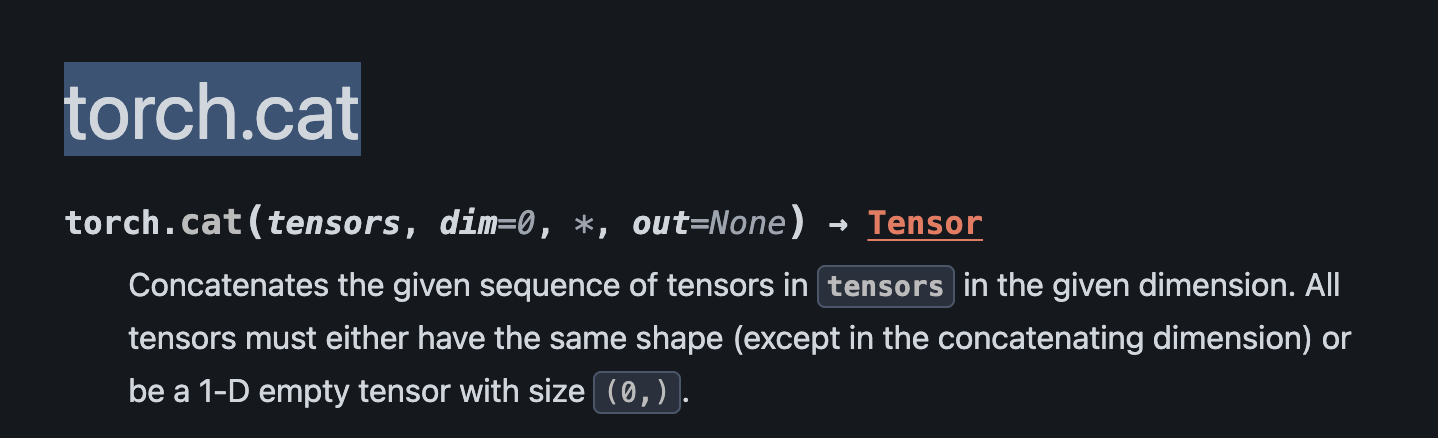

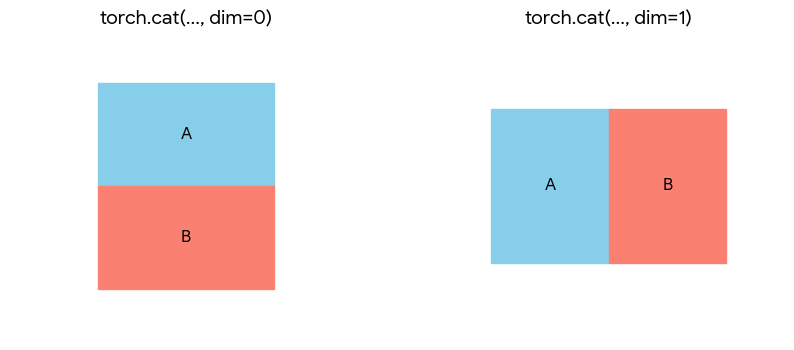

testing the decoder

In [30]:
encoder = Encoder()
x = torch.randn(1, 3, 572, 572)

features = encoder(x)

for i, f in enumerate(features):
    print(f"block {i}: {f.shape}")

block 0: torch.Size([1, 64, 568, 568])
block 1: torch.Size([1, 128, 280, 280])
block 2: torch.Size([1, 256, 136, 136])
block 3: torch.Size([1, 512, 64, 64])
block 4: torch.Size([1, 1024, 28, 28])


here we can see the blocks are reversed for .
so we will first reverse the list and then remove the bottleneck element.

the 1st decoder &harr; 3rd encoder and 2nd decoder &harr; 2nd encoder and so on.

In [ ]:
decoder = Decoder()
x = torch.randn(1,1024,28,28)

features = decoder(x,ftrs[::-1][1:])
#here we are reversing the list and the dropping thr bottleneck element since it is already passed seperately as x to the decoder, it's not a skip connection, it's the main input.

print(features.shape)

torch.Size([1, 64, 388, 388])


##### implementing U-Net

In [47]:
class UNet(nn.Module):
    def __init__(self, enc_chs=(3,64,128,256,512,1024), dec_chs=(1024, 512, 256, 128, 64), num_class=1):
        super().__init__()
        self.encoder = Encoder(enc_chs)
        self.decoder = Decoder(dec_chs)
        self.head = nn.Conv2d(dec_chs[-1], num_class , 1)
    def forward(self,x):
        enc_ftrs = self.encoder(x)
        out = self.decoder(enc_ftrs[::-1][0],enc_ftrs[::-1][1:])
        #self.decoder(bottleneck, [skip connections])
        out = self.head(out) #final 1×1 conv 
        return out

In [48]:
unet = UNet()
x    = torch.randn(1, 3, 572, 572)
unet(x).shape

torch.Size([1, 1, 388, 388])

obtained the paper output!\
done.